<a href="https://colab.research.google.com/github/pramodyasci/scikit-learn-practice/blob/patch-1/scikit_learn_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [2]:
from urllib.request import urlretrieve
import pandas as pd
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline


# **Exploratory analysis**



In [3]:
urlretrieve(url,'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x7f79f537ed50>)

In [4]:
medical_df = pd.read_csv('medical.csv')

In [5]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
medical_df.age.describe()

,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


In [9]:
fig = px.histogram(medical_df,x = 'age', marginal = 'box', nbins = 47,
                   title = 'distribution of age')
fig.update_layout(bargap = 0.1)
fig.show()

In [10]:
fig = px.histogram(medical_df, x = 'bmi', marginal = 'box', color_discrete_sequence = ['blue'], title = 'distribution of bmi')
fig.update_layout(bargap = 0.1)
fig.show()

In [11]:
fig = px.histogram(medical_df, x = 'charges', marginal = 'box',
                   color = 'smoker', color_discrete_sequence = ['green','gray'], title = 'anual medical charges')
fig.update_layout(bargap = 0.1)
fig.show()

In [12]:
fig = px.histogram(medical_df, x = 'charges', marginal = 'box',
                   color = 'sex', color_discrete_sequence = ['blue','red'], title = 'anual medical charges')
fig.update_layout(bargap = 0.1)
fig.show()

In [13]:
fig = px.histogram(medical_df, x = 'charges', marginal = 'box',
                   color = 'region', color_discrete_sequence = ['green','gray','yellow','orange'], title = 'anual medical charges')
fig.update_layout(bargap = 0.1)
fig.show()

In [14]:
medical_df.smoker.value_counts()

,count
smoker,
no,1064
yes,274


In [15]:
px.histogram(medical_df, x = 'smoker', color = 'sex', title = 'smoker')

In [16]:
fig = px.scatter(medical_df, x = 'age', y = 'charges', color = 'smoker', opacity = 0.8, hover_data = ('sex') , title = 'age vs charges')
fig.update_traces(marker_size =5)
fig.show()

In [17]:
fig = px.scatter(medical_df, x = 'bmi', y = 'charges', color = 'smoker', opacity = 0.8, hover_data = ('sex') , title = 'BMI vs charges')
fig.update_traces(marker_size =5)
fig.show()

In [18]:
px.violin(medical_df, x = 'children', y = 'charges')

In [19]:
medical_df['smoker'] = medical_df['smoker'].map({'yes': 1, 'no': 0})
medical_df['sex'] = medical_df['sex'].map({'male': 1, 'female': 0})

In [20]:
medical_df.corr(numeric_only=True)

,age,sex,bmi,children,smoker,charges
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.299008
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.057292
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.198341
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.067998
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,0.787251
charges,0.299008,0.057292,0.198341,0.067998,0.787251,1.000000


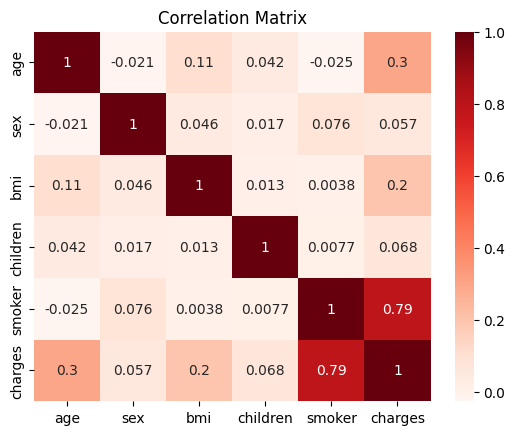

In [21]:
numeric_cols = medical_df.select_dtypes(include=np.number)
sns.heatmap(numeric_cols.corr(), cmap='Reds', annot=True)
plt.title('Correlation Matrix')
plt.show()

# **Linear Regression using a single featue**

In [30]:
non_smoker_df = medical_df[medical_df.smoker == 0]

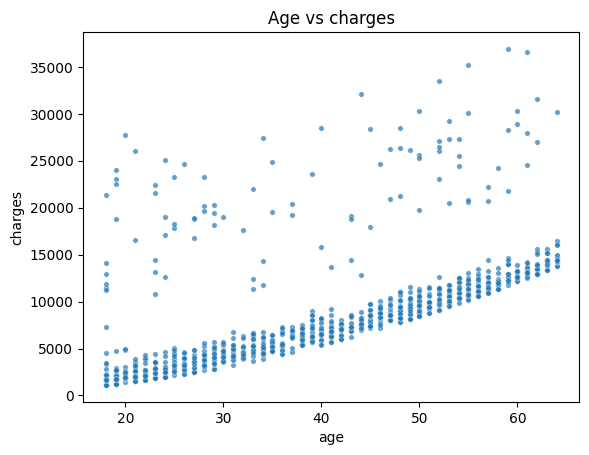

In [31]:
plt.title('Age vs charges')
sns.scatterplot(data= non_smoker_df, x = 'age', y = 'charges', alpha = 0.7, s = 15);

In [32]:
def estimate_charges(age,w,b):
  return w*age +b

In [33]:
w = 50
b = 100

In [40]:
estimate_charges(40, w, b)

2100

In [44]:
ages = non_smoker_df.age
estimated_charges = estimate_charges(ages,w,b)

Text(0, 0.5, 'estimated charges')

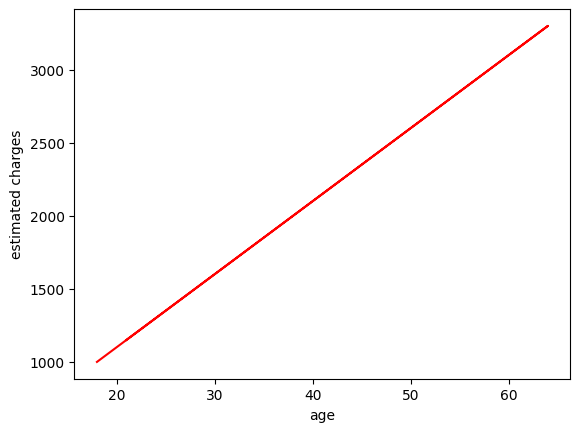

In [48]:
plt.plot(ages,estimated_charges,'r-');
plt.xlabel('age')
plt.ylabel('estimated charges')

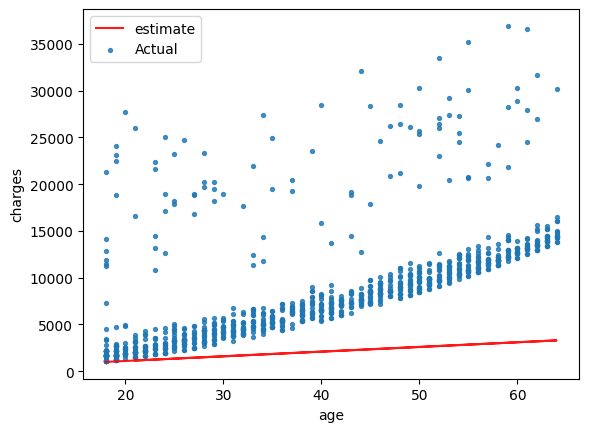

In [49]:
target = non_smoker_df.charges
plt.plot(ages,estimated_charges, 'r', alpha = 0.9)
plt.scatter(ages, target, s = 8, alpha = 0.8)
plt.xlabel('age')
plt.ylabel('charges')
plt.legend(['estimate', 'Actual'])

In [50]:
def try_parameters(w,b):
  ages = non_smoker_df.age
  target = non_smoker_df.charges

  estimated_charges = estimate_charges(ages, w, b)

  plt.plot(ages,estimated_charges, 'r', alpha = 0.9)
  plt.scatter(ages,target, s = 8, alpha = 0.8)
  plt.xlabel('age')
  plt.ylabel('charges')
  plt.legend(['estimate', 'Actual'])

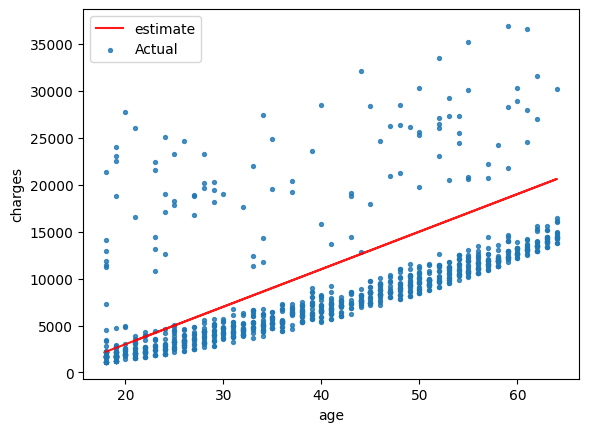

In [53]:
try_parameters(400,-5000)